In [1]:
import pandas as pd, numpy as np

%load_ext autoreload
%autoreload 2

!date

Sat Jul 27 23:08:07 PDT 2024


# HCES Data Extraction
We have HCES data to inform rice consumption (of PSD-distributed and non-PSD rice) by women and birthing people of 
reproductive age (WBPRA) and U5 children in India. We need to do further investigation as to what percentage of PSD-
distributed rice has been fortified with iron and folate.

HCES data and documentation is saved on Sharepoint here: https://uwnetid.sharepoint.com/:f:/r/sites/ihme_simulation_science_team/Shared%20Documents/Research/LSFF/07_Data/HCES_22_data_files?csf=1&web=1&e=wmxQSD

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.
- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

We also will need to approximate DHS wealth quintiles in the HCES data, by using similar variables as is used by the DHS to 
calculate wealth quintiles in India (see DHS wealth quintile documentation here: 
https://dhsprogram.com/programming/wealth%20index/India%20DHS%202015-16/India%202015-16%20sps.txt)

In this notebook, we extract the raw data from the HCES website and do some initial processing in order to create files 
that we can further tabulate based on our project needs in a later step. For now, we process these raw data into dataframes 
that have a row for each household/individual with the following columns:
- Whether or not rice was consumed (binary variable - this will be used to calculate coverage percentages later)
- Amount of PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate fortified rice consumption amount) 
- Amount of non-PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate unfortified rice consumption amount) 
- Wealth composite score/quintile 
- Sex/gender (will be used to calculate WBPRA)
- Age (will be used to tabulate age groups)

## Load data

In [2]:
data_dir = '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023'

In [3]:
level_1_widths = [4, 4, 5, 1, 2, 3, 2, 2, 2, 2, 1, 4, 2, 1, 1, 2, 1, 2, 1, 1, 15]

level_1 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_01.TXT',
    header=None,
    widths=level_1_widths,
    names=[
        "survey_name",
        "year",
        "fsu_serial_no",
        "sector",
        "state",
        "nss_region",
        "district",
        "stratum",
        "sub_stratum",
        "panel",
        "sub_sample",
        "fod_sub_region",
        "sample_su_no",
        "sample_sub_division_no",
        "second_stage_stratum_no",
        "sample_household_no",
        "questionnaire_no",
        "level",
        "survey_code",
        "reason_for_substitution_code",
        "multiplier"
    ],
)
level_1

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,fod_sub_region,sample_su_no,sample_sub_division_no,second_stage_stratum_no,sample_household_no,questionnaire_no,level,survey_code,reason_for_substitution_code,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,2,1,H,1,1,NaN,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,1,H,1,1,NaN,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,2,H,1,1,NaN,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,3,H,1,1,NaN,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,4,H,1,1,NaN,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,14,H,1,1,NaN,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,15,H,1,1,NaN,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,16,H,1,1,NaN,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,17,H,1,1,NaN,73515.0


In [4]:
level_1.sub_sample

0         1
1         1
2         1
3         1
4         1
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: sub_sample, Length: 261746, dtype: int64

In [5]:
level_1.fod_sub_region

0          120
1          120
2          120
3          120
4          120
          ... 
261741    2810
261742    2810
261743    2810
261744    2810
261745    2810
Name: fod_sub_region, Length: 261746, dtype: int64

In [6]:
common_id_columns = level_1.columns[:16]
common_id_column_widths = level_1_widths[:16]

level_1["common_id"] = ""

for col, width in zip(common_id_columns, common_id_column_widths):
    fill_val = '0'
    side = 'left'
    if col in ('sample_su_no', 'sample_sub_division_no', 'panel'):
        # No clue.
        fill_val = ' '
        side = 'right'

    values = level_1[col].fillna(fill_val).astype(str).str.replace('.0', '').str.pad(width, fillchar=fill_val, side=side)
    assert (values.str.len() == width).all()
    level_1["common_id"] += values

level_1["common_id"]

0         HCES2022655561010131113011 101202  201
1         HCES2022655561010131113011 101202  301
2         HCES2022655561010131113011 101202  302
3         HCES2022655561010131113011 101202  303
4         HCES2022655561010131113011 101202  304
                           ...                  
261741    HCES20223951022828313220210228101  314
261742    HCES20223951022828313220210228101  315
261743    HCES20223951022828313220210228101  316
261744    HCES20223951022828313220210228101  317
261745    HCES20223951022828313220210228101  318
Name: common_id, Length: 261746, dtype: object

In [7]:
level_3 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_03.TXT',
    header=None,
    widths=[38,1,2,2,1,3,5,1,1,1,1,1,1,1,1,1,9,1,1,1,1,1,2,1,2,3,1,2,1,1,1,1,2,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "hh_size",
        "household_member_economic_activity_last_365_days",
        "nco_2015_code",
        "nic_2008_code",
        "max_income_source_last_365_days",
        "major_income_source_self_employment_sector",
        "major_income_regular_wage_sector",
        "major_income_casual_labour_sector",
        "household_type",
        "head_religion",
        "head_social_group",
        "land_ownership",
        "land_type_owned",
        "total_owned_land_area",
        "has_dwelling",
        "dwelling_unit_type",
        "building_material_wall",
        "building_material_roof",
        "building_material_floor",
        "cooking_energy_source",
        "lighting_energy_source",
        "drinking_water_source",
        "water_fetching_time_minutes",
        "latrine_access_type",
        "latrine_type",
        "ration_card_type",
        "rural_rent_rate_availability",
        "pmgky_benefit_status",
        "household_child_mortality_last_5_years",
        "child_mortality_count_last_5_years",
        "multiplier",
    ],
)
level_3

,common_id,questionnaire_no,level,hh_size,household_member_economic_activity_last_365_days,nco_2015_code,nic_2008_code,max_income_source_last_365_days,major_income_source_self_employment_sector,major_income_regular_wage_sector,...,drinking_water_source,water_fetching_time_minutes,latrine_access_type,latrine_type,ration_card_type,rural_rent_rate_availability,pmgky_benefit_status,household_child_mortality_last_5_years,child_mortality_count_last_5_years,multiplier
0,HCES2022655561010131113011 101202 201,H,3,5,1,332.0,68200.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,35560.0
1,HCES2022655561010131113011 101202 301,H,3,6,1,931.0,42909.0,3.0,NaN,NaN,...,2,0.0,1,2.0,2,2.0,2,2,0,30331.0
2,HCES2022655561010131113011 101202 302,H,3,8,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
3,HCES2022655561010131113011 101202 303,H,3,4,1,142.0,47713.0,1.0,2.0,NaN,...,2,0.0,1,2.0,0,2.0,2,2,0,30331.0
4,HCES2022655561010131113011 101202 304,H,3,4,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,H,3,2,1,832.0,49219.0,1.0,NaN,NaN,...,11,10.0,1,1.0,4,NaN,1,2,0,73515.0
261742,HCES20223951022828313220210228101 315,H,3,4,1,216.0,85500.0,2.0,NaN,NaN,...,2,0.0,1,1.0,0,NaN,1,2,0,73515.0
261743,HCES20223951022828313220210228101 316,H,3,3,1,411.0,84119.0,2.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0
261744,HCES20223951022828313220210228101 317,H,3,5,1,112.0,47711.0,1.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0


In [8]:
assert level_3.common_id.is_unique

In [9]:
level_3.cooking_energy_source

0         2
1         2
2         2
3         2
4         2
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: cooking_energy_source, Length: 261746, dtype: int64

In [10]:
binary_columns = ["land_ownership", "has_dwelling"]

for col in binary_columns:
    level_3[col] = level_3[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [11]:
level_3.loc[level_3.land_ownership == 0, "total_owned_land_area"] = 0

In [12]:
level_3["dwelling_unit_type"] = level_3.dwelling_unit_type.map({
    1: 'owned',
    2: 'hired',
    3: 'others',
})
level_3["house_ownership"] = (level_3.has_dwelling == 1) & (level_3.dwelling_unit_type == 'owned')

In [13]:
materials = {
    1: 'grass',
    2: 'mud',
    3: 'canvas',
    4: 'katcha',
    5: 'tiles',
    6: 'brick',
    7: 'metal',
    8: 'cement',
    9: 'pucca',
}

for col in ["building_material_wall", "building_material_roof", "building_material_floor"]:
    level_3[col] = level_3[col].map(materials)
    level_3.loc[level_3.has_dwelling == 0, col] = 'none'

In [14]:
level_3["cooking_energy_source"] = level_3.cooking_energy_source.map({
    1: 'firewood',
    2: 'liquid petroleum gas',
    3: 'other natural gas',
    4: 'dung',
    5: 'kerosene',
    6: 'coal',
    7: 'gobar',
    8: 'other biogas',
    10: 'charcoal',
    11: 'electricity',
    12: 'no cooking',
    9: 'other',
})

In [15]:
level_3["lighting_energy_source"] = level_3.lighting_energy_source.map({
    1: 'electricity',
    2: 'kerosene',
    3: 'other oil',
    4: 'gas',
    5: 'candle',
    6: 'no lighting',
    9: 'other',
})

In [16]:
level_3["drinking_water_source"] = level_3.drinking_water_source.map({
    1: 'bottled',
    2: 'piped into dwelling',
    3: 'piped to yard',
    4: 'piped from neighbor',
    5: 'public tap',
    6: 'tube well',
    7: 'hand pump',
    8: 'well: protected',
    9: 'well: unprotected',
    10: 'tanker-truck: public',
    11: 'tanker-truck: private',
    12: 'spring: protected',
    13: 'spring: unprotected',
    14: 'rainwater collection',
    15: 'tank or pond',
    16: 'other surface water',
    19: 'other',
})

In [17]:
level_3["latrine_access_type"] = level_3.latrine_access_type.map({
    1: 'exclusive',
    2: 'common',
    3: 'public, free',
    4: 'public, paid',
    5: 'no latrine',
    9: 'other',
})

In [18]:
level_3["latrine_type"] = level_3.latrine_type.map({
    1: 'flush to piped',
    2: 'flush to septic',
    3: 'flush to twin leach pit',
    4: 'flush to single leach pit',
    5: 'other flush',
    6: 'improved pit',
    7: 'pit with slab',
    8: 'pit without slab',
    10: 'composting',
    11: 'open',
    19: 'other',
})

In [19]:
level_3["latrine_access_and_type"] = np.where(
    level_3.latrine_access_type == 'no latrine',
    'no latrine',
    np.where(
        level_3.latrine_access_type.notnull() & level_3.latrine_type.notnull(),
        (level_3["latrine_access_type"] == 'exclusive').map({True: "", False: "shared "}) + level_3.latrine_type,
        np.nan
    ) 
)

<Axes: >

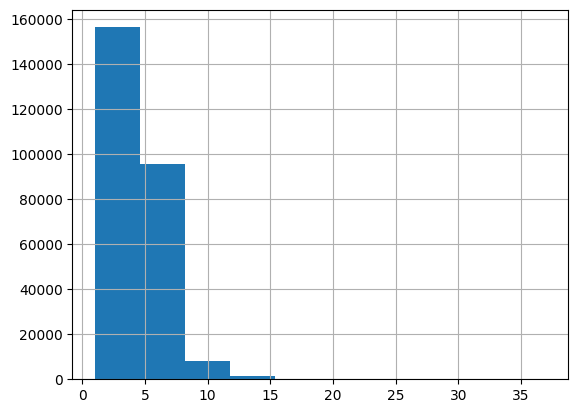

In [20]:
# The fact that there are a couple very large households (e.g. 20+ members) is a little 
# surprising - maybe we can investigate to confirm these are some kind of GQ. 
level_3.hh_size.hist()

In [21]:
level_7 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_07.TXT', 
    header = None, 
    widths = [38,1,2,1,1,2,1,1,3,3,1,3,1,3,1,3,1,3,1,2,1,2,1,1,2,8,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','kerosene','lpg_subsidy','num_lpg_subsidy','days','attend_education',
        'unk','num_attend_priv_ed','free_items','free_textbooks','free_stationary','num_free_stationary',
        'free_school_bag','num_free_school_bag','other_free_items','num_other_free_items','fee_waiver',
        'num_free_waiver','benefit_pmjay','num_benefit_pmjay','hospitalization','pmjay_hosp_benefit',
        'pmjay_hosp_benefit_num','pmjay_hosp_benefit_amt','fuel_light','toilet','education','medicine',
        'services','internet','multiplier'],
)
level_7

,common_id,questionnaire_no,level,kerosene,lpg_subsidy,num_lpg_subsidy,days,attend_education,unk,num_attend_priv_ed,...,pmjay_hosp_benefit,pmjay_hosp_benefit_num,pmjay_hosp_benefit_amt,fuel_light,toilet,education,medicine,services,internet,multiplier
0,HCES2022655561010131113011 101202 201,C,7,2,1,1.0,2,1,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,35560.0
1,HCES2022655561010131113011 101202 301,C,7,2,1,1.0,2,1,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
2,HCES2022655561010131113011 101202 302,C,7,2,1,2.0,2,1,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
3,HCES2022655561010131113011 101202 303,C,7,2,2,NaN,2,1,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
4,HCES2022655561010131113011 101202 304,C,7,2,1,1.0,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261742,HCES20223951022828313220210228101 315,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261743,HCES20223951022828313220210228101 316,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,73515.0
261744,HCES20223951022828313220210228101 317,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0


In [22]:
assert level_7.common_id.is_unique

In [23]:
binary_columns = ["internet"]

for col in binary_columns:
    level_7[col] = level_7[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [24]:
level_11 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_11.TXT', 
    header = None, 
    widths = [38,1,2,1,1,1,1,1,1,1,1,1,1,1,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','clothing','footwear','furniture','recently_bought_mobile_handset',
        'personal_goods','recreation_goods','cooking','crockery','sports_goods','med_equip','bedding','free_laptop',
        'num_free_laptop','free_tablet','num_free_tablet','free_mobile','num_free_mobile','free_bicycle',
        'num_free_bicycle','free_motorcycle','num_free_motorcycle','free_clothing','num_free_clothing',
        'free_footwear','num_free_footwear','other_free','num_other_free','tv','radio','laptop',
        'mobile_handset','bicycle','motorcycle','motor_car','trucks','animal_cart','refrigerator',
        'washing_machine','air_conditioner','multichannel_tv_type','multiplier']
)
level_11

,common_id,questionnaire_no,level,clothing,footwear,furniture,recently_bought_mobile_handset,personal_goods,recreation_goods,cooking,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2022655561010131113011 101202 201,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,NaN,NaN,1.0,1.0,NaN,3.0,35560.0
1,HCES2022655561010131113011 101202 301,D,11,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
2,HCES2022655561010131113011 101202 302,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,3.0,30331.0
3,HCES2022655561010131113011 101202 303,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
4,HCES2022655561010131113011 101202 304,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,2.0,73515.0
261742,HCES20223951022828313220210228101 315,D,11,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,73515.0
261743,HCES20223951022828313220210228101 316,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,73515.0
261744,HCES20223951022828313220210228101 317,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,2.0,73515.0


In [25]:
assert level_11.common_id.is_unique

In [26]:
level_11.tv.value_counts(dropna=False)

tv
1.0    180715
NaN     81031
Name: count, dtype: int64

In [27]:
possession_columns = [
    'tv',
    'radio',
    'laptop',
    'mobile_handset',
    'bicycle',
    'motorcycle',
    'motor_car',
    'trucks',
    'animal_cart',
    'refrigerator',
    'washing_machine',
    'air_conditioner',
]

for col in possession_columns:
    level_11[col] = level_11[col].fillna(0.0)

In [28]:
household_levels = [level_1, level_3, level_7, level_11]

In [29]:
level_specific_columns = ["level", "questionnaire_no"]

def drop_level_specific(df):
    return df[[c for c in df.columns if c not in level_specific_columns]]

households = drop_level_specific(household_levels[0])

for additional_level in household_levels[1:]:
    common_columns = (set(households.columns) & set(additional_level.columns)) - {'common_id'}
    households = households.merge(drop_level_specific(additional_level), on="common_id", validate="1:1")
    for column in common_columns:
        assert (households[f'{column}_x'] == households[f'{column}_y']).all()
        households[column] = households[f'{column}_x']
        households = households.drop(columns=[f'{column}_x', f'{column}_y'])

households

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,73515.0


In [30]:
# Bizarrely, I can't find documentation of these codes -- but we know the rent rate is only asked for rural
households.assign(rent_rate=households.rural_rent_rate_availability.notnull()).groupby('sector').rent_rate.mean()

sector
1    1.0
2    0.0
Name: rent_rate, dtype: float64

In [31]:
households["sector"] = households.sector.map({1: 'rural', 2: 'urban'})
households.sector.value_counts(dropna=False)

sector
rural    155014
urban    106732
Name: count, dtype: int64

## Calculate wealth quintiles

In order to add wealth stratifications into our HCES data, we will emulate DHS methods for calculating wealth quintiles.
They don't ask something like "how wealthy are you?"
Instead, they ask "do you have a refrigerator?" and then a bunch of other questions like that,
and analyze them into a composite wealth index.
The way they do so is actually pretty weird and interesting, but I won't get into that here.
It is described at https://dhsprogram.com/topics/wealth-index/Wealth-Index-Construction.cfm.

In a first pass, we attempted to use the DHS weights directly.
See [this past version of the notebook](https://github.com/ihmeuw/vivarium_gates_lsff_by_wealth_quintile/blob/12d63b4c5a3b7cb204c4f6eb3de7d6ffe87ce9c3/0100_data_prep/01_extract_hces.ipynb)
for how we started to do this.

However, this was tricky,
because none of the questions asked in HCES are exactly the same, with the same answer options,
as in DHS.
We could sort of use proxies and fudge things, but it was pretty rough.
Here, I have instead used the same *methods* used in the DHS to make an entirely new
model of the latent wealth variable.
I followed the steps described here: https://dhsprogram.com/programming/wealth%20index/Steps_to_constructing_the_new_DHS_Wealth_Index.pdf

However, even this is pretty underwhelming. Probably a better strategy to try in the future would be to make a more complex and
precise crosswalk between DHS and HCES questions/responses, then train a model in DHS to predict the DHS wealth quintile based
only on information available in HCES, and finally predict HCES.

DHS wealth index variables include: 
- Source of drinking water
- Type of toilet facility
- Electricity
- Mattress
- Pressure cooker
- Chair
- Cot or bed
- Table
- Electric fan
- Radio or transistor
- Black and white television
- Colour television
- Sewing machine
- Mobile telephone
- Telephone (non-mobile)
- Internet
- Computer
- Refrigerator
- Air conditioner/cooler
- Washing machine
- Watch or clock
- Bicycle
- Motorcycle or Scooter
- Animal-drawn cart
- Car
- Water pump
- Thresher
- Tractor
- Type of cooking fuel
- Main material of floor
- Main roof material
- Main wall material
- Hectares for agricultural land
- Out of this land, how much is irrigated?
- Cows / bulls / buffaloes
- Camels
- Horses / donkeys / mules
- Goats
- Sheep
- Chickens / ducks
- Bank account
- Members per sleeping room
- Compute urban and rural variables coded (1/0) for filters later
- Toilet facility by shared/not shared
- Land area by units - if there are separate units - need to convert them to one unit

HCES variables:
- Type of land owned
- What is the total area of all owned (owned and possessed or leased out) land (within the country) by the household as on the date of survey (area in acre)?(upto two places of decimal) 
- Basic building Material used for major portion of the wall of the dwelling Unit
- Basic building Material used for construction of the major portion of the outer exposed part of the roof of the dwelling unit
- Basic Building Material used for construction of the major portion of the floor of the dwelling Unit
- Source of Drinking Water (Last 365 days)
- Type of latrine in which the household has access
- Primary source of energy of the household for cooking
- Household has internet facility as on the date of the survey
- Whether household possessed one or more item as on the date of the survey- Television 
- Whether household possessed one or more item as on the date of the survey- Radio
- Whether household possessed one or more item as on the date of the survey - Laptop/PC
- Whether household possessed one or more item as on the date of the survey- Mobile handset
- Whether household possessed one or more item as on the date of the survey- Bicycle
- Whether household possessed one or more item as on the date of the survey- Motorcycle, scooter 
- Whether household possessed one or more item as on the date of the survey- Motor car/jeep/van
- Whether household possessed one or more item as on the date of the survey- Trucks
- Whether household possessed one or more item as on the date of the survey - Animal cart
- Whether household possessed one or more item as on the date of the survey- Refrigerator
- Whether household possessed one or more item as on the date of the survey- Washing machine
- Whether household possessed one or more item as on the date of the survey- Air conditioner/air cooler 
- Type of multichannel television facility is used by the household as on the date of the survey

Crosswalk spreadsheet saved here: https://uwnetid.sharepoint.com/sites/ihme_simulation_science_team/_layouts/15/doc.aspx?sourcedoc={eddcbf51-3462-47d7-b847-79edea5046c6}&action=edit

In [32]:
wealth_relevant_info = households[[
    'sector',
    'hh_size',
    'multiplier',
    # Section/level 4
    'land_ownership',
    # 'total_owned_land_area',
    'has_dwelling',
    'house_ownership',
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    # Cross-tab latrine type with whether shared
    'latrine_access_and_type',
    # Section 4.2
    'internet',
    # Section 4.3
    *possession_columns,
]].copy()
wealth_relevant_info

,sector,hh_size,multiplier,land_ownership,has_dwelling,house_ownership,building_material_wall,building_material_roof,building_material_floor,cooking_energy_source,...,laptop,mobile_handset,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner
0,rural,5,35560.0,1.0,1.0,True,brick,cement,cement,liquid petroleum gas,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,rural,6,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,rural,8,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,rural,4,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,rural,4,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,urban,2,73515.0,0.0,1.0,False,brick,cement,tiles,liquid petroleum gas,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
261742,urban,4,73515.0,1.0,1.0,True,brick,tiles,cement,liquid petroleum gas,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
261743,urban,3,73515.0,0.0,1.0,False,brick,tiles,cement,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
261744,urban,5,73515.0,0.0,1.0,False,brick,cement,tiles,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


In [33]:
wealth_relevant_info.isnull().mean()

sector                     0.0
hh_size                    0.0
multiplier                 0.0
land_ownership             0.0
has_dwelling               0.0
house_ownership            0.0
building_material_wall     0.0
building_material_roof     0.0
building_material_floor    0.0
cooking_energy_source      0.0
lighting_energy_source     0.0
drinking_water_source      0.0
latrine_access_and_type    0.0
internet                   0.0
tv                         0.0
radio                      0.0
laptop                     0.0
mobile_handset             0.0
bicycle                    0.0
motorcycle                 0.0
motor_car                  0.0
trucks                     0.0
animal_cart                0.0
refrigerator               0.0
washing_machine            0.0
air_conditioner            0.0
dtype: float64

In [34]:
wealth_relevant_info.nunique()

sector                         2
hh_size                       31
multiplier                 23607
land_ownership                 2
has_dwelling                   2
house_ownership                2
building_material_wall        10
building_material_roof        10
building_material_floor       10
cooking_energy_source         12
lighting_energy_source         7
drinking_water_source         17
latrine_access_and_type       22
internet                       2
tv                             2
radio                          2
laptop                         2
mobile_handset                 2
bicycle                        2
motorcycle                     2
motor_car                      2
trucks                         2
animal_cart                    2
refrigerator                   2
washing_machine                2
air_conditioner                2
dtype: int64

In [35]:
columns_to_convert = [
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    'latrine_access_and_type',
]

for column in columns_to_convert:
    # Get dummy variables for the current column
    dummies = pd.get_dummies(wealth_relevant_info[column], prefix=column)
    
    # Drop the original column from hces_df
    wealth_relevant_info = wealth_relevant_info.drop(column, axis=1)
    
    # Join the dummy variables to the original DataFrame
    wealth_relevant_info = pd.concat([wealth_relevant_info, dummies], axis=1)

In [36]:
wealth_predictors = [c for c in wealth_relevant_info.columns if c not in ('sector', 'hh_size', 'multiplier')]

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).dropna(how='any'))

PCA(n_components=1)

In [38]:
pd.DataFrame({
    "column": wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).columns,
    "scores": pd.Series(pca.components_[0]).astype(float),
}).sort_values('scores')

,column,scores
50,cooking_energy_source_firewood,-0.332121
42,building_material_floor_mud,-0.211374
66,drinking_water_source_hand pump,-0.201371
31,building_material_roof_metal,-0.157884
8,bicycle,-0.135724
...,...,...
9,motorcycle,0.246566
4,tv,0.264903
28,building_material_roof_cement,0.269550
53,cooking_energy_source_liquid petroleum gas,0.341292


In [39]:
wealth_relevant_info["common_score"] = pca.transform(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']))

In [40]:
wealth_relevant_info.sector.value_counts()

sector
rural    155014
urban    106732
Name: count, dtype: int64

In [41]:
scores = {}

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    pca = PCA(n_components=1)
    pca.fit(wealth_relevant_info[sector_rows][wealth_predictors].dropna(how='any'))

    display(pd.DataFrame({
        "column": wealth_predictors,
        "scores": pd.Series(pca.components_[0]).astype(float),
    }).sort_values('scores'))

    wealth_relevant_info.loc[sector_rows, f"{sector}_score"] = pca.transform(wealth_relevant_info[sector_rows][wealth_predictors])

urban


,column,scores
38,building_material_floor_cement,-0.202654
31,building_material_roof_metal,-0.184361
95,latrine_access_and_type_shared flush to septic,-0.096225
50,cooking_energy_source_firewood,-0.088282
71,drinking_water_source_piped to yard,-0.077376
...,...,...
45,building_material_floor_tiles,0.284999
15,air_conditioner,0.303321
9,motorcycle,0.309448
14,washing_machine,0.367206


rural


,column,scores
50,cooking_energy_source_firewood,-0.359039
42,building_material_floor_mud,-0.273167
66,drinking_water_source_hand pump,-0.222534
8,bicycle,-0.143104
88,latrine_access_and_type_no latrine,-0.138695
...,...,...
28,building_material_roof_cement,0.243380
9,motorcycle,0.271464
13,refrigerator,0.289802
4,tv,0.301591


In [42]:
import statsmodels.api as sm

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    mod = sm.OLS(wealth_relevant_info[sector_rows][['common_score']], sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))
    fii = mod.fit()
    print(fii.summary2())

    wealth_relevant_info.loc[sector_rows, "combined_score"] = fii.predict(sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))

urban
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.853     
Dependent Variable: common_score     AIC:                43078.2973
Date:               2024-07-27 23:08 BIC:                43097.4535
No. Observations:   106732           Log-Likelihood:     -21537.   
Df Model:           1                F-statistic:        6.193e+05 
Df Residuals:       106730           Prob (F-statistic): 0.00      
R-squared:          0.853            Scale:              0.087660  
---------------------------------------------------------------------
              Coef.    Std.Err.      t       P>|t|    [0.025   0.975]
---------------------------------------------------------------------
const         0.6506     0.0009   717.8467   0.0000   0.6488   0.6523
urban_score   0.7990     0.0010   786.9735   0.0000   0.7970   0.8010
-------------------------------------------------------------------
Omnibus:            17128.237      Durbin-Watson: 

<Axes: >

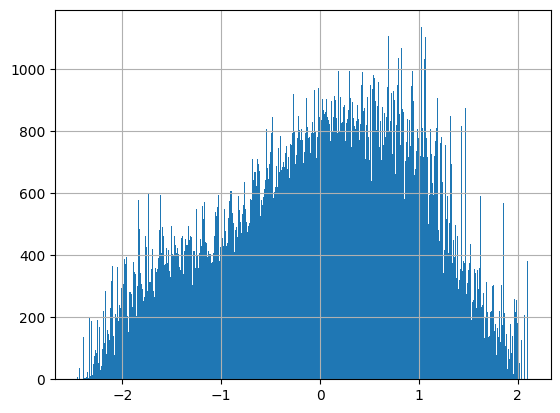

In [43]:
wealth_relevant_info.combined_score.hist(bins=500)

In [44]:
wealth_relevant_info['weighted_household_size'] = wealth_relevant_info.hh_size * wealth_relevant_info.multiplier

from statsmodels.stats.weightstats import DescrStatsW
wq = DescrStatsW(data=wealth_relevant_info.combined_score, weights=wealth_relevant_info.weighted_household_size)
quintile_cutoffs = wq.quantile(probs=np.linspace(0, 1, 6))
quintile_cutoffs

p
0.0   -2.453442
0.2   -1.142439
0.4   -0.339699
0.6    0.296405
0.8    0.887782
1.0    2.106418
dtype: float64

In [45]:
wealth_relevant_info["wealth_quintile"] = pd.cut(wealth_relevant_info.combined_score, quintile_cutoffs, labels=["lowest", "second", "middle", "fourth", "highest"])
wealth_relevant_info["wealth_quintile"]

0         highest
1          fourth
2          fourth
3          fourth
4          fourth
           ...   
261741    highest
261742    highest
261743     fourth
261744    highest
261745     middle
Name: wealth_quintile, Length: 261746, dtype: category
Categories (5, object): ['lowest' < 'second' < 'middle' < 'fourth' < 'highest']

In [46]:
wealth_relevant_info.groupby("wealth_quintile", observed=True).multiplier.sum() / wealth_relevant_info.multiplier.sum()

wealth_quintile
lowest     0.194799
second     0.197195
middle     0.210537
fourth     0.198687
highest    0.198759
Name: multiplier, dtype: float64

In [47]:
for column in wealth_predictors:
    print(column)
    print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())

land_ownership
wealth_quintile  land_ownership
lowest           0.0               0.017003
                 1.0               0.982997
second           0.0               0.064876
                 1.0               0.935124
middle           0.0               0.121395
                 1.0               0.878605
fourth           0.0               0.084162
                 1.0               0.915838
highest          0.0               0.078404
                 1.0               0.921596
Name: multiplier, dtype: float64
has_dwelling
wealth_quintile  has_dwelling
lowest           0.0             0.000067
                 1.0             0.999933
second           0.0             0.000251
                 1.0             0.999749
middle           1.0             1.000000
fourth           1.0             1.000000
highest          1.0             1.000000
Name: multiplier, dtype: float64
house_ownership
wealth_quintile  house_ownership
lowest           False              0.023655
                

/tmp/ipykernel_3291438/3807259362.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())


wealth_quintile  refrigerator
lowest           0.0             0.992774
                 1.0             0.007226
second           0.0             0.923492
                 1.0             0.076508
middle           0.0             0.733672
                 1.0             0.266328
fourth           0.0             0.359606
                 1.0             0.640394
highest          0.0             0.029776
                 1.0             0.970224
Name: multiplier, dtype: float64
washing_machine
wealth_quintile  washing_machine
lowest           0.0                0.998997
                 1.0                0.001003
second           0.0                0.987101
                 1.0                0.012899
middle           0.0                0.940825
                 1.0                0.059175
fourth           0.0                0.814637
                 1.0                0.185363
highest          0.0                0.338265
                 1.0                0.661735
Name: multiplier, 

wealth_quintile  building_material_roof_cement
lowest           False                            0.846248
                 True                             0.153752
second           False                            0.562032
                 True                             0.437968
middle           False                            0.434384
                 True                             0.565616
fourth           False                            0.285982
                 True                             0.714018
highest          False                            0.067651
                 True                             0.932349
Name: multiplier, dtype: float64
building_material_roof_grass
wealth_quintile  building_material_roof_grass
lowest           False                           0.829236
                 True                            0.170764
second           False                           0.968669
                 True                            0.031331
middle           False 

wealth_quintile  building_material_floor_none
lowest           False                           0.999933
                 True                            0.000067
second           False                           0.999749
                 True                            0.000251
middle           False                           1.000000
fourth           False                           1.000000
highest          False                           1.000000
Name: multiplier, dtype: float64
building_material_floor_pucca
wealth_quintile  building_material_floor_pucca
lowest           False                            0.969784
                 True                             0.030216
second           False                            0.957308
                 True                             0.042692
middle           False                            0.964569
                 True                             0.035431
fourth           False                            0.976391
                 True    

wealth_quintile  lighting_energy_source_candle
lowest           False                            0.990230
                 True                             0.009770
second           False                            0.995259
                 True                             0.004741
middle           False                            0.999163
                 True                             0.000837
fourth           False                            0.999958
                 True                             0.000042
highest          False                            0.999923
                 True                             0.000077
Name: multiplier, dtype: float64
lighting_energy_source_electricity
wealth_quintile  lighting_energy_source_electricity
lowest           False                                 0.038441
                 True                                  0.961559
second           False                                 0.013126
                 True                              

wealth_quintile  drinking_water_source_public tap
lowest           False                               0.912015
                 True                                0.087985
second           False                               0.883178
                 True                                0.116822
middle           False                               0.889810
                 True                                0.110190
fourth           False                               0.910388
                 True                                0.089612
highest          False                               0.962901
                 True                                0.037099
Name: multiplier, dtype: float64
drinking_water_source_rainwater collection
wealth_quintile  drinking_water_source_rainwater collection
lowest           False                                         0.999216
                 True                                          0.000784
second           False                            

wealth_quintile  latrine_access_and_type_flush to twin leach pit
lowest           False                                              0.922339
                 True                                               0.077661
second           False                                              0.915728
                 True                                               0.084272
middle           False                                              0.938471
                 True                                               0.061529
fourth           False                                              0.938853
                 True                                               0.061147
highest          False                                              0.983871
                 True                                               0.016129
Name: multiplier, dtype: float64
latrine_access_and_type_improved pit
wealth_quintile  latrine_access_and_type_improved pit
lowest           False                   

wealth_quintile  latrine_access_and_type_shared other
lowest           False                                   0.992333
                 True                                    0.007667
second           False                                   0.991839
                 True                                    0.008161
middle           False                                   0.995870
                 True                                    0.004130
fourth           False                                   0.998639
                 True                                    0.001361
highest          False                                   0.999935
                 True                                    0.000065
Name: multiplier, dtype: float64
latrine_access_and_type_shared other flush
wealth_quintile  latrine_access_and_type_shared other flush
lowest           False                                         0.991208
                 True                                          0.008792
second

In [48]:
# Whoa, owning land or a house is uncorrelated?!

india_dhs = pd.read_stata(
    "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/IND_DHS7_2015_2016_HH_IAHR74FL_Y2018M12D06.DTA", columns=["hv005", "hv270", "sh46"]
).rename(columns={"hv005": "weight", "hv270": "wealth_quintile", "sh46": "owns_house"})

In [49]:
india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()

/tmp/ipykernel_3291438/2344698748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()


wealth_quintile  owns_house
poorest          no            0.174830
                 yes           0.825170
poorer           no            0.179612
                 yes           0.820388
middle           no            0.213271
                 yes           0.786729
richer           no            0.248677
                 yes           0.751323
richest          no            0.191180
                 yes           0.808820
Name: weight, dtype: float64

In [50]:
# Bizarre. Even in DHS it's basically uncorrelated, although in HCES it seems to be reversed.

In [51]:
households["wealth_quintile"] = wealth_relevant_info["wealth_quintile"]

## Household rice consumption

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.

- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

Units: kg/30 days.

In [52]:
consumption = pd.read_fwf(
    f'{data_dir}/hces22_lvl_05.TXT',
    header=None,
    widths = [38,1,2,3,10,8,10,8,1,15],
    names=['common_id','q_num','level','item_code','consumption_amt_home_produce',
        'consumption_value_home_produce','total_consumption_amt','total_consumption_value',
        'source','multiplier'],
)
consumption = consumption[consumption.item_code.isin([61, 101, 102])]
consumption

,common_id,q_num,level,item_code,consumption_amt_home_produce,consumption_value_home_produce,total_consumption_amt,total_consumption_value,source,multiplier
0,HCES2022655561010131113011 101202 201,F,5,102,NaN,NaN,40,1200.0,1.0,35560.0
26,HCES2022655561010131113011 101202 301,F,5,102,40,950,40,950.0,2.0,30331.0
53,HCES2022655561010131113011 101202 302,F,5,102,30,900,36,1020.0,3.0,30331.0
80,HCES2022655561010131113011 101202 303,F,5,102,NaN,NaN,25,500.0,1.0,30331.0
106,HCES2022655561010131113011 101202 304,F,5,102,20,600,20,600.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...
9314493,HCES20223951022828313220210228101 316,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314531,HCES20223951022828313220210228101 317,F,5,61,NaN,NaN,10.00,NaN,1.0,73515.0
9314532,HCES20223951022828313220210228101 317,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314576,HCES20223951022828313220210228101 318,F,5,61,NaN,NaN,5.00,NaN,1.0,73515.0


In [53]:
consumption["item_code"] = consumption.item_code.map({
    61: 'pds free rice',
    101: 'pds paid rice',
    102: 'other rice',
})
consumption["is_pds"] = consumption.item_code.isin(['pds free rice', 'pds paid rice'])

In [54]:
consumption["source"] = consumption.source.map({
    1: 'only purchase',
    2: 'only home-grown',
    3: 'both purchase and home-grown',
    4: 'only free collection',
    5: 'only exchange',
    6: 'only gifts',
    9: 'other',
})

In [55]:
consumption["total_consumption_amt"] = consumption.total_consumption_amt.astype(float)
consumption["consumption_amt_home_produce"] = consumption.consumption_amt_home_produce.astype(float)

In [56]:
consumption.isnull().mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.933018
consumption_value_home_produce    0.933031
total_consumption_amt             0.000000
total_consumption_value           0.261820
source                            0.000000
multiplier                        0.000000
is_pds                            0.000000
dtype: float64

In [57]:
consumption = consumption.fillna(0)

In [58]:
consumption["pds_rice"] = np.where(
    consumption.is_pds,
    consumption.total_consumption_amt,
    0.0,
)

In [59]:
consumption["non_pds_rice_purchased"] = np.where(
    consumption.is_pds,
    0.0,
    np.where(
        consumption.source.isin(['only purchase', 'both purchase and home-grown']),
        consumption.total_consumption_amt - consumption.consumption_amt_home_produce,
        0.0,
    )
)

In [60]:
consumption["non_pds_rice_non_purchased"] = consumption.total_consumption_amt - consumption.pds_rice - consumption.non_pds_rice_purchased

In [61]:
consumption = consumption.groupby("common_id")[["pds_rice", "non_pds_rice_purchased", "non_pds_rice_non_purchased"]].sum()
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased
common_id,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0
...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0


In [62]:
consumption["rice"] = consumption.sum(axis=1)
# NOTE: As of 2024 the scale-up of fortification in PDS is still ongoing,
# but we assume it will be complete by 2030.
consumption["fortified_rice"] = consumption.pds_rice
consumption["proportion_fortifiable"] = (consumption.pds_rice + consumption.non_pds_rice_purchased) / consumption.rice
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,fortified_rice,proportion_fortifiable
common_id,,,,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,0.0,1.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,6.0,1.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,3.0,1.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,3.0,1.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,1.0
...,...,...,...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,30.0,1.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,10.0,1.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,20.0,1.0


## Individual rice consumption

We distribute the rice to the individuals according to the number of meals they have eaten at home.
We assume that children eating school lunches are getting fortified rice, as the scale-up has also
happened through that program.
Otherwise, we assume that meals eaten away from the home use rice and fortified rice at the same rate
as meals at home.

In [63]:
household_members = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_02.TXT',
    header=None,
    widths=[38,1,2,2,1,1,3,1,2,2,1,2,1,2,2,2,2,2,1,1,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "person_serial_no",
        "relation_to_head_code",
        "gender",
        "age_years",
        "marital_status_code",
        "highest_education_level_code",
        "total_years_education",
        "internet_use_last_30_days",
        "days_away_from_home_last_30_days",
        "usual_daily_meals",
        "meals_from_school_balwadi_last_30_days",
        "meals_from_employer_last_30_days",
        "meals_others_last_30_days",
        "meals_paid_last_30_days",
        "meals_at_home_last_30_days",
        "member_status_on_revisit",
        "fdq_orig_number",
        "multiplier",
    ],
)
household_members

,common_id,questionnaire_no,level,person_serial_no,relation_to_head_code,gender,age_years,marital_status_code,highest_education_level_code,total_years_education,...,days_away_from_home_last_30_days,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,member_status_on_revisit,fdq_orig_number,multiplier
0,HCES2022655561010131113011 101202 201,H,2,1,1,1,48,2,6,12.0,...,0.0,2.0,0.0,0.0,0.0,0.0,58.0,1,1.0,35560.0
1,HCES2022655561010131113011 101202 201,H,2,2,2,2,46,2,1,NaN,...,0.0,2.0,NaN,NaN,NaN,NaN,60.0,1,1.0,35560.0
2,HCES2022655561010131113011 101202 201,H,2,3,5,1,24,1,13,18.0,...,0.0,2.0,NaN,NaN,NaN,NaN,58.0,1,1.0,35560.0
3,HCES2022655561010131113011 101202 201,H,2,4,5,1,18,1,7,13.0,...,0.0,2.0,NaN,NaN,NaN,NaN,56.0,1,1.0,35560.0
4,HCES2022655561010131113011 101202 201,H,2,5,5,2,21,1,12,17.0,...,0.0,2.0,NaN,NaN,NaN,NaN,54.0,1,1.0,35560.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,H,2,1,1,1,40,2,12,17.0,...,0.0,2.0,0.0,0.0,0.0,5.0,55.0,1,1.0,938.0
1127035,HCES20223492023737102120110201201 313,H,2,2,2,2,38,2,6,12.0,...,0.0,2.0,0.0,0.0,0.0,0.0,60.0,1,1.0,938.0
1127036,HCES20223492023737102120110201201 313,H,2,3,5,1,12,1,4,7.0,...,0.0,2.0,0.0,0.0,0.0,0.0,60.0,1,1.0,938.0
1127037,HCES20223492023737102120110201201 313,H,2,4,5,2,7,1,3,2.0,...,0.0,2.0,0.0,0.0,0.0,0.0,60.0,1,1.0,938.0


In [64]:
household_members["gender"] = household_members.gender.map({
    1: 'male',
    2: 'female',
    3: 'transgender',
})

In [65]:
household_members = household_members.merge(households[["common_id", "wealth_quintile"]], on="common_id", validate="m:1")

In [66]:
household_members["meals"] = (
    household_members.meals_at_home_last_30_days + household_members.meals_from_employer_last_30_days + household_members.meals_from_school_balwadi_last_30_days +
    household_members.meals_from_employer_last_30_days + household_members.meals_paid_last_30_days + household_members.meals_others_last_30_days
)

<Axes: xlabel='usual_daily_meals', ylabel='meals'>

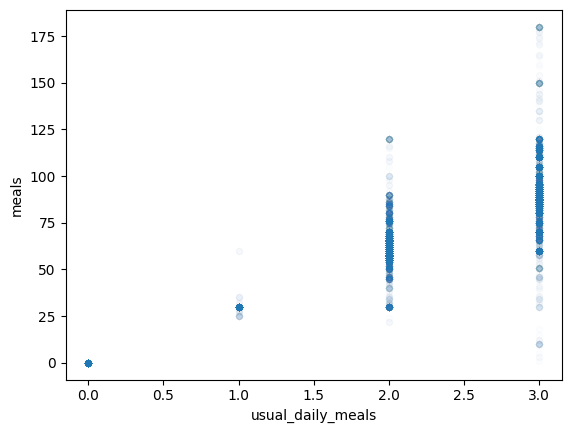

In [67]:
household_members.plot(kind='scatter', x='usual_daily_meals', y='meals', alpha=0.01)

In [68]:
household_meals = household_members.groupby("common_id").meals_at_home_last_30_days.sum()
household_meals

common_id
HCES2022310002282831212025 228111  301     30.0
HCES2022310002282831212025 228111  302    408.0
HCES2022310002282831212025 228111  303    450.0
HCES2022310002282831212025 228111  304    180.0
HCES2022310002282831212025 228111  305     30.0
                                          ...  
HCES2022699991212130123093 221201  312    671.0
HCES2022699991212130123093 221201  313    180.0
HCES2022699991212130123093 221201  314    360.0
HCES2022699991212130123093 221201  315    333.0
HCES2022699991212130123093 221201  316    480.0
Name: meals_at_home_last_30_days, Length: 261746, dtype: float64

In [69]:
consumption = consumption.merge(household_meals, on="common_id", validate="1:1")
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,fortified_rice,proportion_fortifiable,meals_at_home_last_30_days
common_id,,,,,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,0.0,1.0,30.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,6.0,1.0,408.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,3.0,1.0,450.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,3.0,1.0,180.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,1.0,30.0
...,...,...,...,...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,30.0,1.0,671.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,10.0,1.0,180.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,20.0,1.0,360.0


In [70]:
consumption[(consumption.rice > 0) & (consumption.meals_at_home_last_30_days == 0)]

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,fortified_rice,proportion_fortifiable,meals_at_home_last_30_days
common_id,,,,,,,
HCES2022310142272712260074 127202 311,0.00,2.0,0.0,2.00,0.00,1.0,0.0
HCES2022310382272712260064 227202 307,0.00,2.0,0.0,2.00,0.00,1.0,0.0
HCES2022310742282831112019 128131 310,5.65,0.0,0.0,5.65,5.65,1.0,0.0
HCES2022312232272712412017 127211 301,0.00,4.0,0.0,4.00,0.00,1.0,0.0
HCES2022313562242420748011 224101 307,0.00,4.0,0.0,4.00,0.00,1.0,0.0
...,...,...,...,...,...,...,...
HCES2022698161222231623021 222101 316,2.00,0.0,0.0,2.00,2.00,1.0,0.0
HCES2022698301222222523015 222121 309,35.00,0.0,0.0,35.00,35.00,1.0,0.0
HCES2022698761222220723041 222122 303,20.00,10.0,0.0,30.00,20.00,1.0,0.0


In [71]:
consumption["rice_per_meal_kg"] = np.where(
    consumption.rice == 0,
    0.0,
    consumption.rice / consumption.meals_at_home_last_30_days
)

In [72]:
# In a small number of cases, rice consumption is reported despite very few or no meals at home
impossible_rice_consumption = (consumption.rice > 0) & (consumption.meals_at_home_last_30_days == 0)
consumption[impossible_rice_consumption]

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,fortified_rice,proportion_fortifiable,meals_at_home_last_30_days,rice_per_meal_kg
common_id,,,,,,,,
HCES2022310142272712260074 127202 311,0.00,2.0,0.0,2.00,0.00,1.0,0.0,inf
HCES2022310382272712260064 227202 307,0.00,2.0,0.0,2.00,0.00,1.0,0.0,inf
HCES2022310742282831112019 128131 310,5.65,0.0,0.0,5.65,5.65,1.0,0.0,inf
HCES2022312232272712412017 127211 301,0.00,4.0,0.0,4.00,0.00,1.0,0.0,inf
HCES2022313562242420748011 224101 307,0.00,4.0,0.0,4.00,0.00,1.0,0.0,inf
...,...,...,...,...,...,...,...,...
HCES2022698161222231623021 222101 316,2.00,0.0,0.0,2.00,2.00,1.0,0.0,inf
HCES2022698301222222523015 222121 309,35.00,0.0,0.0,35.00,35.00,1.0,0.0,inf
HCES2022698761222220723041 222122 303,20.00,10.0,0.0,30.00,20.00,1.0,0.0,inf


In [73]:
# This must be wrong somehow, so we clip it
consumption["rice_per_meal_kg"] = consumption["rice_per_meal_kg"].clip(upper=np.percentile(consumption.rice_per_meal_kg, 95))

In [74]:
consumption.sort_values('rice_per_meal_kg')

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,fortified_rice,proportion_fortifiable,meals_at_home_last_30_days,rice_per_meal_kg
common_id,,,,,,,,
HCES2022658851080820821016 108211 302,0.0,0.20,0.0,0.20,0.0,1.0,690.0,0.000290
HCES2022654751060621323071 106123 301,0.0,0.25,0.0,0.25,0.0,1.0,600.0,0.000417
HCES2022666431080811823192 108116 304,0.0,0.50,0.0,0.50,0.0,1.0,1080.0,0.000463
HCES2022650131080822423082 108101 201,0.0,0.20,0.0,0.20,0.0,1.0,420.0,0.000476
HCES2022663371080821023225 108233 306,0.0,0.25,0.0,0.25,0.0,1.0,502.0,0.000498
...,...,...,...,...,...,...,...,...
HCES2022699991212130123093 221201 315,35.0,35.00,0.0,70.00,35.0,1.0,333.0,0.183333
HCES2022310032282831112022 128131 304,20.0,2.00,0.0,22.00,20.0,1.0,120.0,0.183333
HCES2022699991212130123093 221201 201,30.0,70.00,0.0,100.00,30.0,1.0,540.0,0.183333


<Axes: >

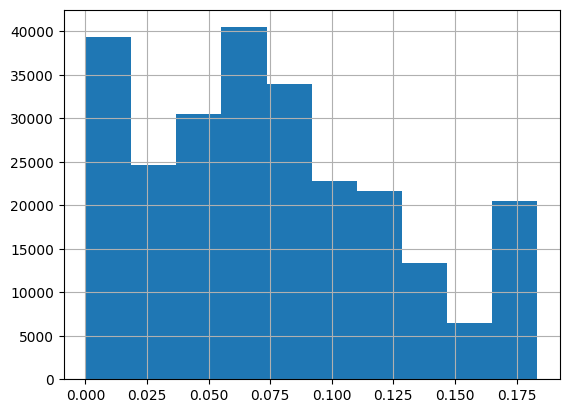

In [75]:
consumption.rice_per_meal_kg.hist()

<Axes: >

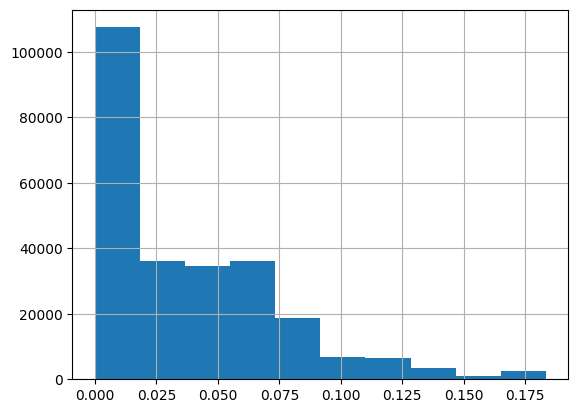

In [76]:
consumption["fortified_rice_per_meal_kg"] = consumption.rice_per_meal_kg * (consumption.fortified_rice / consumption.rice)
consumption.fortified_rice_per_meal_kg.hist()

In [77]:
household_members = household_members.merge(consumption.reset_index()[["common_id", "rice_per_meal_kg", "fortified_rice_per_meal_kg", "proportion_fortifiable"]], on="common_id")
household_members["fortified_meals_away_from_home"] = household_members.meals_from_school_balwadi_last_30_days
household_members["normal_meals_away_from_home"] = household_members.meals - household_members.meals_at_home_last_30_days - household_members.fortified_meals_away_from_home
household_members["rice"] = (
    household_members.meals_at_home_last_30_days * household_members.rice_per_meal_kg +
    (household_members.fortified_meals_away_from_home * household_members.rice_per_meal_kg) +
    (household_members.normal_meals_away_from_home * household_members.rice_per_meal_kg)
)
household_members["fortified_rice"] = (
    household_members.meals_at_home_last_30_days * household_members.fortified_rice_per_meal_kg +
    (household_members.fortified_meals_away_from_home * household_members.rice_per_meal_kg) +
    (household_members.normal_meals_away_from_home * household_members.fortified_rice_per_meal_kg)
)
household_members["proportion_fortified"] = household_members.fortified_rice / household_members.rice
household_members["proportion_fortifiable"] = (
    (household_members.fortified_rice + (household_members.proportion_fortifiable * (household_members.rice - household_members.fortified_rice))) /
    household_members.rice
)

In [78]:
# Convert kg/30 days to g/day
household_members["rice_g_per_day"] = household_members.rice / 30 * 1_000

### WRA (proxy for pregnant people)

In [79]:
wra_df = household_members[(household_members.gender == 'female') & (household_members.age_years >= 10) & (household_members.age_years < 55)]
wra_df

,common_id,questionnaire_no,level,person_serial_no,relation_to_head_code,gender,age_years,marital_status_code,highest_education_level_code,total_years_education,...,meals,rice_per_meal_kg,fortified_rice_per_meal_kg,proportion_fortifiable,fortified_meals_away_from_home,normal_meals_away_from_home,rice,fortified_rice,proportion_fortified,rice_g_per_day
1,HCES2022655561010131113011 101202 201,H,2,2,2,female,46,2,1,NaN,...,NaN,0.139860,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HCES2022655561010131113011 101202 201,H,2,5,5,female,21,1,12,17.0,...,NaN,0.139860,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,HCES2022655561010131113011 101202 301,H,2,2,2,female,45,2,1,NaN,...,NaN,0.112360,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,HCES2022655561010131113011 101202 301,H,2,5,5,female,19,1,7,13.0,...,NaN,0.112360,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,HCES2022655561010131113011 101202 302,H,2,3,4,female,33,2,1,NaN,...,NaN,0.076433,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1104578,HCES20223492023737102120110201201 308,H,2,5,5,female,28,1,13,17.0,...,60.0,0.102740,0.068493,1.0,0.0,2.0,6.164384,4.109589,0.666667,205.479452
1104587,HCES20223492023737102120110201201 310,H,2,3,4,female,28,2,7,14.0,...,60.0,0.117188,0.078125,1.0,0.0,0.0,7.031250,4.687500,0.666667,234.375000
1104596,HCES20223492023737102120110201201 312,H,2,2,2,female,45,2,6,12.0,...,60.0,0.108696,0.065217,1.0,0.0,3.0,6.521739,3.913043,0.600000,217.391304
1104598,HCES20223492023737102120110201201 312,H,2,4,5,female,12,1,5,8.0,...,60.0,0.108696,0.065217,1.0,0.0,0.0,6.521739,3.913043,0.600000,217.391304


In [80]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [81]:
pregnancy_sim_data_dir = '../../0200_pregnancy_sim/src/vivarium_gates_lsff_by_wealth_quintile/data/raw_data'

In [82]:
def save_data(series, name):
    (
        series.rename("value").reset_index()
            .assign(vehicle_name='rice')
            .to_csv(f'{pregnancy_sim_data_dir}/{name}/india.csv', index=False)
    )

In [83]:
any_consumption = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))
    .sort_index()
)
any_consumption

/tmp/ipykernel_3291438/2507177430.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/2507177430.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.268730,0.443299,15090.691222
second,0.271008,0.444480,47526.484584
middle,0.290249,0.453877,54723.466514
fourth,0.311348,0.463045,53425.432221
highest,0.310127,0.462545,48251.545369


In [84]:
save_data(any_consumption["mean"], "vehicle_consumption/any")

In [85]:
consumption_amount = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)
consumption_amount

/tmp/ipykernel_3291438/1175765591.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/1175765591.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,222.748520,129.040421,14423.990951
second,177.989489,122.246053,15214.434457
middle,167.499632,120.400479,15841.834851
fourth,166.855498,121.261643,17662.484347
highest,126.812776,108.744019,15863.779004


In [86]:
save_data(consumption_amount["mean"], "vehicle_consumption/amount/mean")
save_data(consumption_amount["sd"], "vehicle_consumption/amount/sd")

In [87]:
any_fortification = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortified > 0, weights=df.multiplier))
    .sort_index()
)
any_fortification

/tmp/ipykernel_3291438/1258123976.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/1258123976.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortified > 0, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.235631,0.424393,15090.691222
second,0.221419,0.415202,47526.484584
middle,0.218289,0.413085,54723.466514
fourth,0.215432,0.411122,53425.432221
highest,0.128486,0.334630,48251.545369


In [88]:
save_data(any_fortification["mean"], "baseline_fortification/any_coverage")

In [89]:
full_fortification = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortified == 1, weights=df.multiplier))
    .sort_index()
)
full_fortification

/tmp/ipykernel_3291438/1698430511.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/1698430511.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortified == 1, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.074010,0.261788,15090.691222
second,0.084330,0.277883,47526.484584
middle,0.081774,0.274020,54723.466514
fourth,0.070544,0.256062,53425.432221
highest,0.036878,0.188463,48251.545369


In [90]:
save_data(full_fortification["mean"], "baseline_fortification/full_coverage")

In [91]:
partial_fortification_amount = (
    wra_df[(wra_df.proportion_fortified > 0) & (wra_df.proportion_fortified < 1)].groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortified, weights=df.multiplier))
    .sort_index()
)
partial_fortification_amount

/tmp/ipykernel_3291438/3198127737.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df[(wra_df.proportion_fortified > 0) & (wra_df.proportion_fortified < 1)].groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/3198127737.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortified, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.553091,0.186866,8836.731794
second,0.565975,0.188935,7737.236641
middle,0.550457,0.191325,7073.327515
fourth,0.526549,0.194810,7866.178612
highest,0.487097,0.212984,4568.751776


In [92]:
save_data(partial_fortification_amount["mean"], "baseline_fortification/partial_coverage_amount/mean")
save_data(partial_fortification_amount["sd"], "baseline_fortification/partial_coverage_amount/sd")

In [93]:
fortifiability_disparities = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))
    .sort_index()
)
fortifiability_disparities

/tmp/ipykernel_3291438/3717732404.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_3291438/3717732404.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.932994,0.178282,14423.990951
second,0.944953,0.174817,15214.434457
middle,0.959307,0.160688,15841.834851
fourth,0.960913,0.163543,17662.392892
highest,0.965384,0.170576,15862.927952


In [94]:
# Save locally for further scaling in the extraction notebook
fortifiability_disparities["mean"].rename("value").to_csv('india_fortifiability_disparities.csv')